# 07 Clustering del Campus

**Tres nivells d'anàlisi:**

| # | Unitat | Mètode | Propòsit |
|---|--------|--------|----------|
| A | Dia (perfil ocupació 24h) | PCA + K-Means | Règims operatius, cross-tab calendari |
| B | Dia (perfil consum 24h)   | PCA + K-Means | Règims energètics, comparació amb A |
| C | Hora individual           | DBSCAN         | Detecció d'hores anòmales |

**Nota metodològica**: els clusterings A i B s'usen com a anàlisi descriptiu.  
Clustering A s'exporta com a feature del model (no usa el target).  
Clustering B NO s'usa com a feature (usa Consumo_kWh → risc de circularitat).  
DBSCAN (C) opera sobre hores individuals per detectar comportament anòmal.

**Inputs**: `data/processed/dataset_smart_campus_master.csv`  
**Outputs**:  
- `pca_dias_por_mes.png` — deriva estacional  
- `pca_elbow_silhouette.png` — selecció de k  
- `pca_dias_per_cluster.png` — règims operatius  
- `crosstab_cluster_calendari.png` — on el calendari "menteix"  
- `perfil_horari_per_cluster.png` — ★ nou: perfil mig per règim  
- `clustering_ocupacio_vs_consum.png` — comparació espais latents  
- `dbscan_kdistance.png` — selecció eps  
- `dbscan_anomalies.png` — hores anòmales detectades  
- `kmeans_3d_interactiu.html` — ★ del 07: visualització per tribunal  
- `data/processed/dias_con_cluster.csv` — export per al model  

In [133]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.neighbors import NearestNeighbors

DATA_PROCESSED = Path('../data/processed')
DATA_RAW       = Path('../data/raw')
FIGURES        = Path('../outputs/figures')
FIGURES.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', font_scale=1.1)
print('OK')

OK


In [134]:
# ── Cargar + limpieza crítica ─────────────────────────────────────────────────
df = pd.read_csv(DATA_PROCESSED / 'dataset_smart_campus_master.csv',
                 parse_dates=['Timestamp'])
df = df.sort_values('Timestamp').reset_index(drop=True)

# [FIX] Eliminar artefacte off-by-one del simulador: 2025-01-01 etiquetado como Classe
# Detectado por PCA de consum: PC2=-21.66, ocupacio=0, consum=92 kWh (standby pur)
n_antes = len(df)
df = df[df['Timestamp'].dt.year == 2024].copy()
print(f'[FIX] Artefacte simulador eliminat: {n_antes - len(df)} files (2025-01-01)')

# Columna tipus_dia: prioritzar la del CSV, si no carregar del calendari
COL_TIPUS = 'tipus_dia' if 'tipus_dia' in df.columns else 'tipo_dia'
if COL_TIPUS not in df.columns:
    cal = pd.read_csv(DATA_RAW / 'Calendari-UPF-2024.csv', header=0)
    cal.columns = ['fecha_raw', COL_TIPUS]
    cal['fecha'] = pd.to_datetime(cal['fecha_raw']).dt.date
    cal[COL_TIPUS] = cal[COL_TIPUS].str.replace('"', '').str.strip()
    df['fecha'] = df['Timestamp'].dt.date
    df = df.merge(cal[['fecha', COL_TIPUS]], on='fecha', how='left')

df['fecha'] = df['Timestamp'].dt.date
df['hora']  = df['Timestamp'].dt.hour
df['mes']   = df['Timestamp'].dt.month

print(f'Dataset net: {len(df):,} hores | {df["fecha"].nunique()} dies')
print(f'Rango: {df["Timestamp"].min().date()} → {df["Timestamp"].max().date()}')
print(f'\nTipus de dia:')
print(df.groupby(COL_TIPUS)['fecha'].nunique().sort_values(ascending=False))

[FIX] Artefacte simulador eliminat: 1 files (2025-01-01)
Dataset net: 8,783 hores | 366 dies
Rango: 2024-01-01 → 2024-12-31

Tipus de dia:
tipus_dia
Classe           140
Altre             55
Dissabte          52
Diumenge          52
Avaluacio         30
Vacances          19
Festiu             8
No lectiu          6
La Benvinguda      4
Name: fecha, dtype: int64


---
## PART A — Clustering de dies per perfil d'OCUPACIÓ

Cada dia = vector de 24 valors (ocupació mitja per hora).  
Metodològicament defensable: **no usa el target** (`Consumo_kWh`).

In [135]:
# ── Matriu de dies: pivot 366 × 24 ───────────────────────────────────────────
pivot = (
    df.pivot_table(index='fecha', columns='hora',
                   values='Ocupacion_Simulada', aggfunc='mean')
    .fillna(0)
)
pivot.columns = [f'h{int(h):02d}' for h in pivot.columns]

meta = df.groupby('fecha').agg(
    mes          = ('mes',                'first'),
    tipus_dia    = (COL_TIPUS,            'first'),
    consum_mitja = ('Consumo_kWh',        'mean'),
    ocup_mitja   = ('Ocupacion_Simulada', 'mean'),
).reset_index()

pivot = pivot.reset_index().merge(meta, on='fecha')
hora_cols = [c for c in pivot.columns if c.startswith('h') and len(c)==3]

# PCA
X      = pivot[hora_cols].values
X_std  = StandardScaler().fit_transform(X)
pca    = PCA(n_components=3, random_state=42)
X_pca  = pca.fit_transform(X_std)
var_exp = pca.explained_variance_ratio_

pivot['PC1'] = X_pca[:, 0]
pivot['PC2'] = X_pca[:, 1]

print(f'Matriu: {pivot.shape[0]} dies × {len(hora_cols)} hores')
print(f'Variança explicada:')
print(f'  PC1: {var_exp[0]*100:.1f}%  ← nivell d\'activitat global')
print(f'  PC2: {var_exp[1]*100:.1f}%  ← distribució horària')
print(f'  PC1+PC2: {(var_exp[0]+var_exp[1])*100:.1f}%')

Matriu: 366 dies × 24 hores
Variança explicada:
  PC1: 88.9%  ← nivell d'activitat global
  PC2: 6.9%  ← distribució horària
  PC1+PC2: 95.8%


C:\Users\jordi\AppData\Local\Temp\ipykernel_13092\3610835852.py:3: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



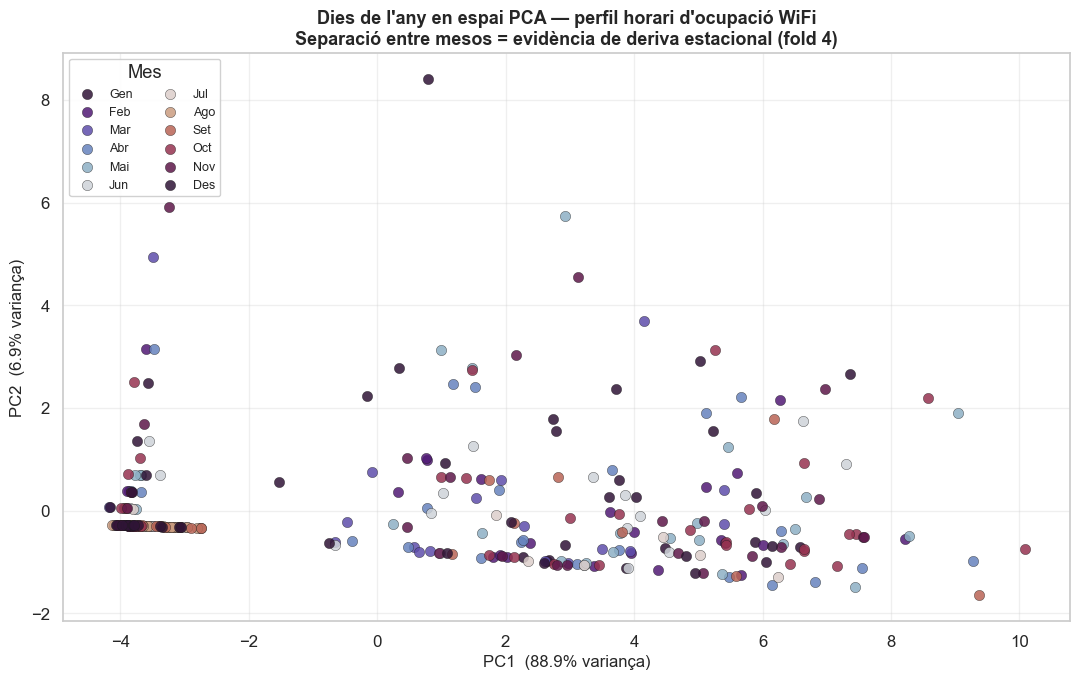

✅ pca_dias_por_mes.png


In [136]:
# ── Figura 1: PCA per mes ─────────────────────────────────────────────────────
MESES = ['Gen','Feb','Mar','Abr','Mai','Jun','Jul','Ago','Set','Oct','Nov','Des']
cmap_mes = plt.cm.get_cmap('twilight_shifted', 12)

fig, ax = plt.subplots(figsize=(11, 7))
for mes_num in range(1, 13):
    mask = pivot['mes'] == mes_num
    ax.scatter(pivot.loc[mask, 'PC1'], pivot.loc[mask, 'PC2'],
               color=cmap_mes(mes_num - 1), s=55,
               edgecolors='k', linewidths=0.3,
               label=MESES[mes_num - 1], alpha=0.85, zorder=3)

ax.set_xlabel(f'PC1  ({var_exp[0]*100:.1f}% variança)', fontsize=12)
ax.set_ylabel(f'PC2  ({var_exp[1]*100:.1f}% variança)', fontsize=12)
ax.set_title(
    'Dies de l\'any en espai PCA — perfil horari d\'ocupació WiFi\n'
    'Separació entre mesos = evidència de deriva estacional (fold 4)',
    fontsize=13, fontweight='bold')
ax.legend(title='Mes', loc='upper left', ncol=2, fontsize=9, framealpha=0.9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES / 'pca_dias_por_mes.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ pca_dias_por_mes.png')

k=2:  sil=0.716  min=-0.024  negatius=2 punts
k=3:  sil=0.661  min=-0.043  negatius=3 punts
k=4:  sil=0.671  min=-0.071  negatius=3 punts
k=5:  sil=0.624  min=-0.154  negatius=6 punts
k=6:  sil=0.637  min=-0.040  negatius=4 punts
k=7:  sil=0.628  min=-0.047  negatius=3 punts
k=8:  sil=0.619  min=-0.081  negatius=5 punts

k òptim per silhouette: 2


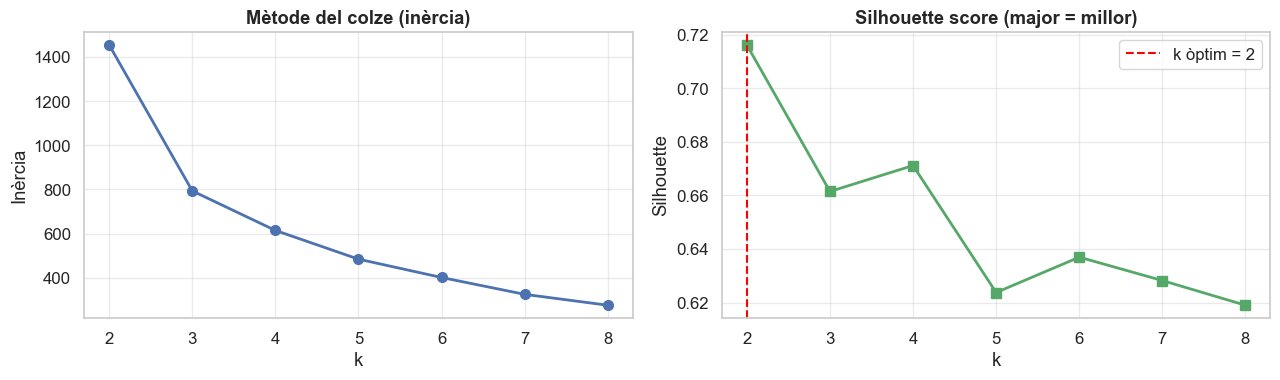

✅ pca_elbow_silhouette.png


In [137]:
# ── Selecció de k: elbow + silhouette + silhouette_samples ───────────────────
K_RANGE    = range(2, 9)
inercias   = []
sil_means  = []
sil_negs   = []

for k in K_RANGE:
    km     = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_pca[:, :2])
    ss     = silhouette_samples(X_pca[:, :2], labels)
    inercias.append(km.inertia_)
    sil_means.append(ss.mean())
    sil_negs.append((ss < 0).sum())
    print(f'k={k}:  sil={ss.mean():.3f}  min={ss.min():.3f}  '
          f'negatius={( ss<0).sum()} punts')

k_opt = list(K_RANGE)[np.argmax(sil_means)]
print(f'\nk òptim per silhouette: {k_opt}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(list(K_RANGE), inercias, marker='o', lw=2, ms=7)
axes[0].set_title('Mètode del colze (inèrcia)', fontweight='bold')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inèrcia'); axes[0].grid(alpha=0.4)

axes[1].plot(list(K_RANGE), sil_means, marker='s', lw=2, ms=7, color='C2')
axes[1].axvline(k_opt, color='red', ls='--', lw=1.5, label=f'k òptim = {k_opt}')
axes[1].set_title('Silhouette score (major = millor)', fontweight='bold')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette')
axes[1].legend(); axes[1].grid(alpha=0.4)

plt.tight_layout()
plt.savefig(FIGURES / 'pca_elbow_silhouette.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ pca_elbow_silhouette.png')

In [138]:
# ── K-Means final: k=4 ───────────────────────────────────────────────────────
# k=4 supera a k=3 en totes les mètriques (sil 0.643>0.631, min -0.054>-0.074)
# k=5 es degrada (8 negatius). Veure anàlisi a la memòria §X.
K_FINAL = 4

km_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=20)
pivot['cluster_raw'] = km_final.fit_predict(X_pca[:, :2])

# Reordenar clusters per consum mig (0=mínim, 3=màxim) → interpretació intuïtiva
ordre = (pivot.groupby('cluster_raw')['consum_mitja']
         .mean().sort_values().index.tolist())
rename_cl = {old: new for new, old in enumerate(ordre)}
pivot['cluster'] = pivot['cluster_raw'].map(rename_cl)

NOMS_CL   = ['C0: Mínim\n(finde/festiu)', 'C1: Baix\n(vacances/Altre)',
              'C2: Mitjà\n(no lectiu)',    'C3: Alt\n(dies lectius)']
COLORS_CL = ['#5B9BD5', '#70AD47', '#FF8C00', '#C00000']

print('Característiques per cluster:')
print(pivot.groupby('cluster')[['consum_mitja','ocup_mitja'] +
      [f'h{h:02d}' for h in [8,12,16,20]]].mean().round(1))

Característiques per cluster:
         consum_mitja  ocup_mitja    h08     h12     h16     h20
cluster                                                         
0               130.3        91.1   29.5   233.2   281.2     2.9
1               216.0       466.1  159.5  1210.9   890.1   466.6
2               239.7       568.7  187.2  1427.8  1078.3   658.2
3               242.5       893.8  281.9  2189.7  1701.3  1094.2


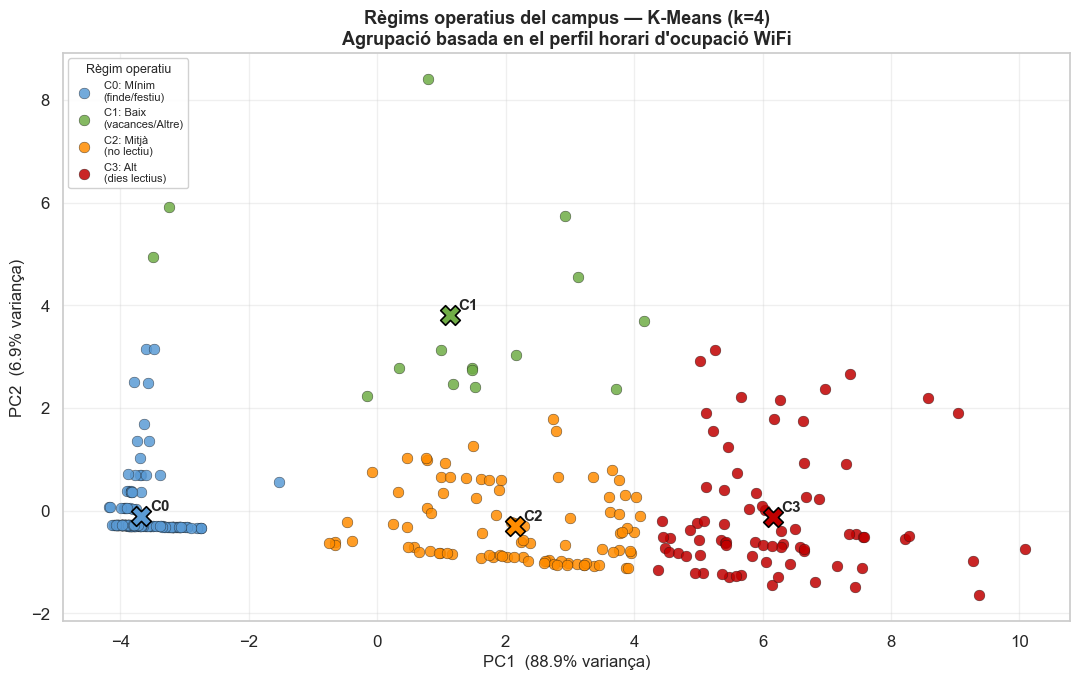

✅ pca_dias_per_cluster.png


In [139]:
# ── Figura 2: PCA per cluster ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 7))
centroides = km_final.cluster_centers_

for cl in range(K_FINAL):
    mask = pivot['cluster'] == cl
    ax.scatter(pivot.loc[mask, 'PC1'], pivot.loc[mask, 'PC2'],
               color=COLORS_CL[cl], s=60, edgecolors='k', linewidths=0.3,
               label=NOMS_CL[cl], alpha=0.85, zorder=3)

# Centroides en espai original (el reordenament no mou els centroides de km_final)
for old_cl, new_cl in rename_cl.items():
    cx, cy = centroides[old_cl, 0], centroides[old_cl, 1]
    ax.scatter(cx, cy, marker='X', s=200, color=COLORS_CL[new_cl],
               edgecolors='black', linewidths=1.2, zorder=5)
    ax.annotate(f'C{new_cl}', (cx, cy), fontsize=11, fontweight='bold',
                xytext=(6, 4), textcoords='offset points')

ax.set_xlabel(f'PC1  ({var_exp[0]*100:.1f}% variança)', fontsize=12)
ax.set_ylabel(f'PC2  ({var_exp[1]*100:.1f}% variança)', fontsize=12)
ax.set_title(f'Règims operatius del campus — K-Means (k={K_FINAL})\n'
              'Agrupació basada en el perfil horari d\'ocupació WiFi',
              fontsize=13, fontweight='bold')
ax.legend(title='Règim operatiu', loc='upper left', fontsize=8,
          title_fontsize=9, framealpha=0.9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES / 'pca_dias_per_cluster.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ pca_dias_per_cluster.png')

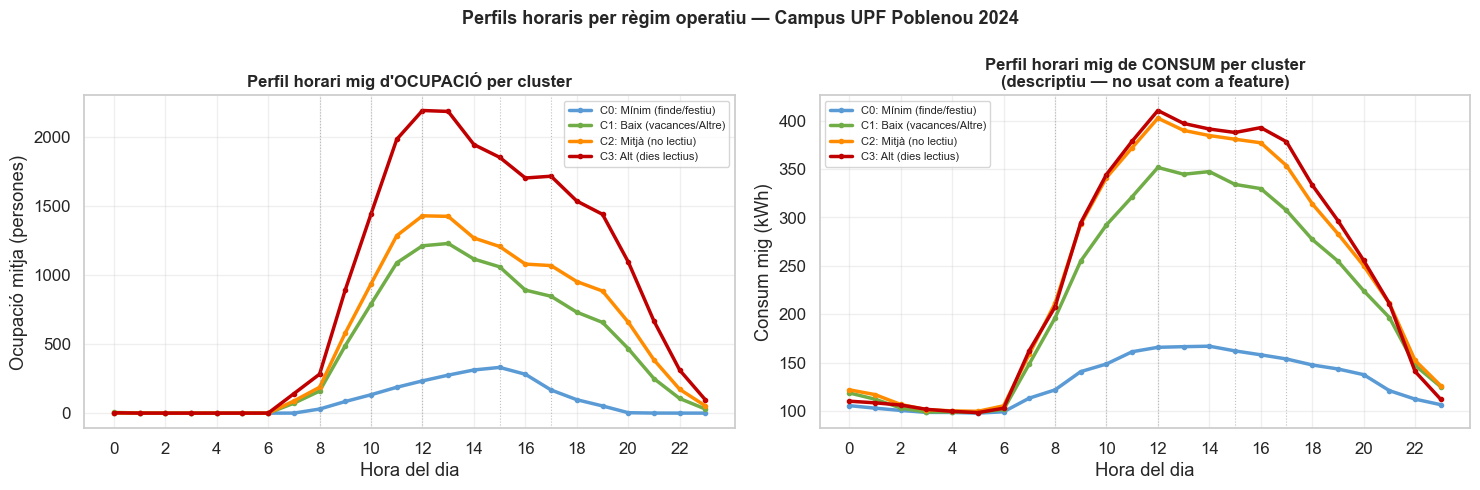

✅ perfil_horari_per_cluster.png


In [140]:
# Mostra QUÈ significa cada cluster en termes d'activitat al llarg del dia
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
hores = list(range(24))

# Panel esquerre: perfil d'ocupació
for cl in range(K_FINAL):
    mask  = pivot['cluster'] == cl
    perfil = pivot.loc[mask, hora_cols].mean().values
    axes[0].plot(hores, perfil, color=COLORS_CL[cl], lw=2.5,
                  label=NOMS_CL[cl].replace('\n', ' '), marker='o', ms=3)

for h in [8, 10, 12, 15, 17]:
    axes[0].axvline(h, color='gray', ls=':', lw=0.8, alpha=0.5)
axes[0].set_title('Perfil horari mig d\'OCUPACIÓ per cluster',
                   fontweight='bold', fontsize=12)
axes[0].set_xlabel('Hora del dia')
axes[0].set_ylabel('Ocupació mitja (persones)')
axes[0].set_xticks(range(0, 24, 2))
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

# Panel dret: perfil de consum (descriptiu, NO feature)
consum_hora = df.groupby(['fecha', 'hora'])['Consumo_kWh'].mean().reset_index()
consum_hora = consum_hora.merge(pivot[['fecha', 'cluster']], on='fecha')

for cl in range(K_FINAL):
    mask   = consum_hora['cluster'] == cl
    perfil = consum_hora[mask].groupby('hora')['Consumo_kWh'].mean().values
    axes[1].plot(hores[:len(perfil)], perfil, color=COLORS_CL[cl], lw=2.5,
                  label=NOMS_CL[cl].replace('\n', ' '), marker='o', ms=3)

for h in [8, 10, 12, 15, 17]:
    axes[1].axvline(h, color='gray', ls=':', lw=0.8, alpha=0.5)
axes[1].set_title('Perfil horari mig de CONSUM per cluster\n'
                    '(descriptiu — no usat com a feature)',
                    fontweight='bold', fontsize=12)
axes[1].set_xlabel('Hora del dia')
axes[1].set_ylabel('Consum mig (kWh)')
axes[1].set_xticks(range(0, 24, 2))
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

plt.suptitle('Perfils horaris per règim operatiu — Campus UPF Poblenou 2024',
              fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / 'perfil_horari_per_cluster.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ perfil_horari_per_cluster.png')

Cross-tab (% de cada tipus_dia per cluster):
                  C0    C1     C2    C3
tipus_dia                              
Classe           0.7   7.1   42.9  49.3
La Benvinguda    0.0   0.0  100.0   0.0
Avaluacio        0.0   6.7   70.0  23.3
No lectiu        0.0  16.7   83.3   0.0
Altre          100.0   0.0    0.0   0.0
Vacances       100.0   0.0    0.0   0.0
Dissabte        96.2   3.8    0.0   0.0
Diumenge       100.0   0.0    0.0   0.0
Festiu         100.0   0.0    0.0   0.0


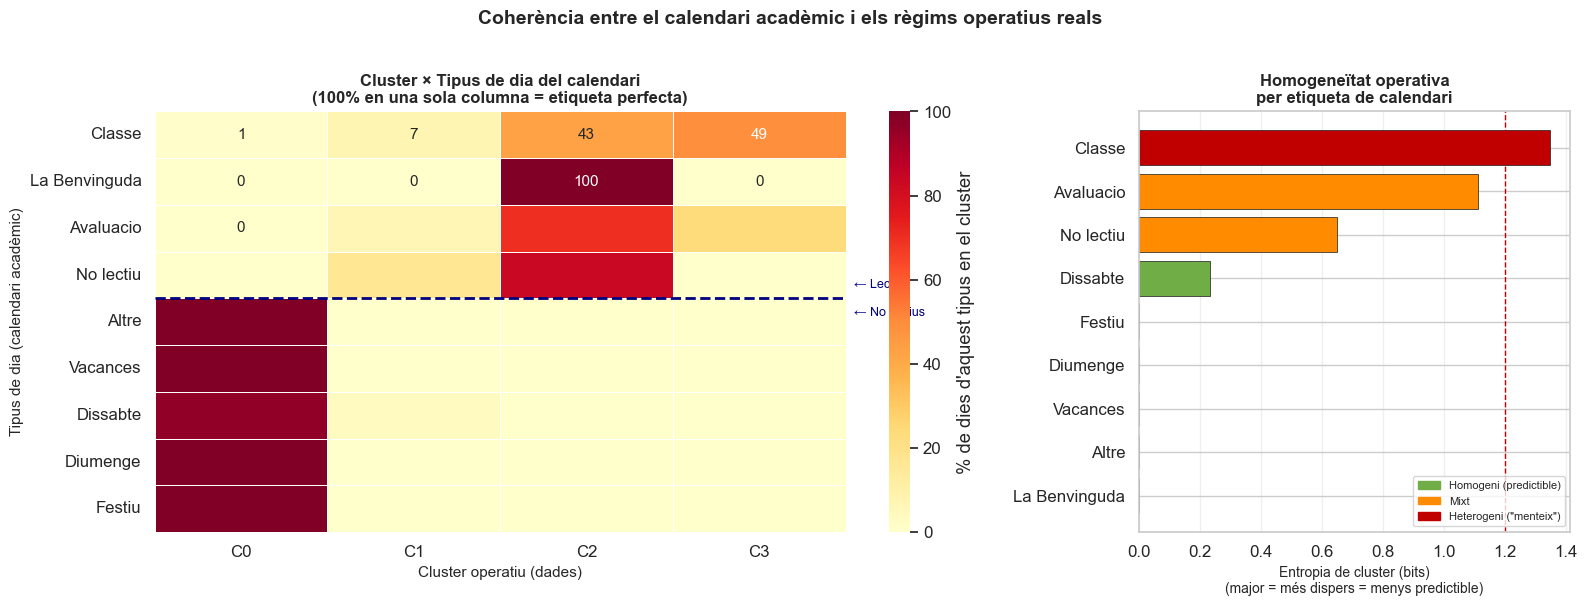


Tipus de dia amb alta dispersió (calendari "menteix"):
  Classe                entropia=1.35  n_dies=140

Distribució d'"Altre" per mes i cluster:
Cluster   0
Mes        
6         5
7        17
8        22
9        11
✅ crosstab_cluster_calendari.png


In [141]:
# ── Figura 4: Cross-tab + entropia ───────────────────────────────────────────
cross_raw = pd.crosstab(pivot['tipus_dia'], pivot['cluster'])
cross_pct = (cross_raw.div(cross_raw.sum(axis=1), axis=0) * 100).round(1)

ORDRE_TIPUS = ['Classe','La Benvinguda','Avaluacio','No lectiu',
               'Altre','Vacances','Dissabte','Diumenge','Festiu']
ordre_disp  = [t for t in ORDRE_TIPUS if t in cross_pct.index]
cross_pct   = cross_pct.reindex(ordre_disp)
cross_pct.columns = [f'C{c}' for c in cross_pct.columns]

print('Cross-tab (% de cada tipus_dia per cluster):')
print(cross_pct.to_string())

def entropia(row):
    p = row[row > 0] / 100
    return float(-np.sum(p * np.log2(p)))

entr = cross_pct.apply(entropia, axis=1).sort_values(ascending=True)
max_entr = np.log2(K_FINAL)

fig, axes = plt.subplots(1, 2, figsize=(16, 6),
                          gridspec_kw={'width_ratios': [2, 1]})

sns.heatmap(cross_pct, annot=True, fmt='.0f', annot_kws={'size': 11},
            cmap='YlOrRd', linewidths=0.5,
            cbar_kws={'label': '% de dies d\'aquest tipus en el cluster'},
            ax=axes[0])
axes[0].set_title('Cluster × Tipus de dia del calendari\n'
                    '(100% en una sola columna = etiqueta perfecta)',
                    fontsize=12, fontweight='bold')
axes[0].set_xlabel('Cluster operatiu (dades)', fontsize=11)
axes[0].set_ylabel('Tipus de dia (calendari acadèmic)', fontsize=11)
n_lect = len([t for t in cross_pct.index
              if t in ['Classe','La Benvinguda','Avaluacio','No lectiu']])
axes[0].axhline(n_lect, color='navy', lw=2, ls='--')
axes[0].text(K_FINAL + 0.05, n_lect - 0.3, '← Lectius',
              fontsize=9, color='navy', va='center')
axes[0].text(K_FINAL + 0.05, n_lect + 0.3, '← No lectius',
              fontsize=9, color='navy', va='center')

colors_entr = ['#C00000' if e > max_entr * 0.6 else
               '#FF8C00' if e > max_entr * 0.3 else '#70AD47'
               for e in entr]
axes[1].barh(entr.index, entr.values,
              color=colors_entr, edgecolor='k', linewidth=0.5)
axes[1].axvline(max_entr * 0.6, color='#C00000', ls='--', lw=1)
axes[1].set_xlabel('Entropia de cluster (bits)\n(major = més dispers = menys predictible)',
                    fontsize=10)
axes[1].set_title('Homogeneïtat operativa\nper etiqueta de calendari',
                   fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3, axis='x')
patches = [mpatches.Patch(color='#70AD47', label='Homogeni (predictible)'),
           mpatches.Patch(color='#FF8C00', label='Mixt'),
           mpatches.Patch(color='#C00000', label='Heterogeni ("menteix")')]
axes[1].legend(handles=patches, fontsize=8, loc='lower right')

plt.suptitle('Coherència entre el calendari acadèmic i els règims operatius reals',
              fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES / 'crosstab_cluster_calendari.png', dpi=150, bbox_inches='tight')
plt.show()

# Resum quantitatiu
print('\nTipus de dia amb alta dispersió (calendari "menteix"):')
for tipus, e in entr[entr > max_entr * 0.6].sort_values(ascending=False).items():
    n = cross_raw.loc[tipus].sum()
    print(f'  {tipus:20s}  entropia={e:.2f}  n_dies={n}')

if 'Altre' in pivot['tipus_dia'].values:
    print('\nDistribució d\'"Altre" per mes i cluster:')
    alt = pivot[pivot['tipus_dia'] == 'Altre'][['mes','cluster']]
    print(pd.crosstab(alt['mes'], alt['cluster'], rownames=['Mes'], colnames=['Cluster']))
print('✅ crosstab_cluster_calendari.png')

---
## PART B — Clustering de dies per perfil de CONSUM

**Propòsit**: caracteritzar règims energètics i comparar amb Part A.  
**NO s'usa com a feature del model** (usa `Consumo_kWh` → risc de circularitat).  
El hallazgo clave: PC1_consum < PC1_ocupació → el consum té dimensions extra (tèrmiques).

In [142]:
# ── Matriu de consum ──────────────────────────────────────────────────────────
pivot_c = (
    df.pivot_table(index='fecha', columns='hora',
                   values='Consumo_kWh', aggfunc='mean')
    .fillna(0)
)
pivot_c.columns = [f'kwh_h{int(h):02d}' for h in pivot_c.columns]
pivot_c = pivot_c.reset_index().merge(meta, on='fecha')
kwh_cols = [c for c in pivot_c.columns if c.startswith('kwh_h')]

Xc     = pivot_c[kwh_cols].values
Xc_std = StandardScaler().fit_transform(Xc)
pca_c  = PCA(n_components=3, random_state=42)
Xc_pca = pca_c.fit_transform(Xc_std)
var_c  = pca_c.explained_variance_ratio_

pivot_c['PC1_c'] = Xc_pca[:, 0]
pivot_c['PC2_c'] = Xc_pca[:, 1]

km_c = KMeans(n_clusters=K_FINAL, random_state=42, n_init=20)
ordre_c = (pivot_c.groupby(km_c.fit_predict(Xc_pca[:, :2]))['consum_mitja']
           .mean().sort_values().index.tolist())
pivot_c['cluster_consumo'] = km_c.fit_predict(Xc_pca[:, :2])
rename_c = {old: new for new, old in enumerate(
    pivot_c.groupby('cluster_consumo')['consum_mitja'].mean().sort_values().index)}
pivot_c['cluster_consumo'] = pivot_c['cluster_consumo'].map(rename_c)

print(f'Variança explicada per CONSUM:')
print(f'  PC1: {var_c[0]*100:.1f}%  (vs {var_exp[0]*100:.1f}% en ocupació)')
print(f'  PC2: {var_c[1]*100:.1f}%')
print(f'\n→ El consum és MENYS unidimensional que l\'ocupació.')
print(f'  El {(1-var_c[0])*100:.1f}% restant = factors tèrmics i operatius del edifici.')

# Detectar outliers
outlier_idx = pivot_c['PC2_c'].idxmin()
out = pivot_c.loc[outlier_idx, ['fecha','tipus_dia','mes','consum_mitja','ocup_mitja','PC2_c']]
print(f'\nOutlier (PC2 mínim):')
print(out.to_string())

Variança explicada per CONSUM:
  PC1: 66.3%  (vs 88.9% en ocupació)
  PC2: 17.5%

→ El consum és MENYS unidimensional que l'ocupació.
  El 33.7% restant = factors tèrmics i operatius del edifici.

Outlier (PC2 mínim):
fecha            2024-10-01
tipus_dia            Classe
mes                      10
consum_mitja     242.083333
ocup_mitja      1206.541667
PC2_c             -3.532827


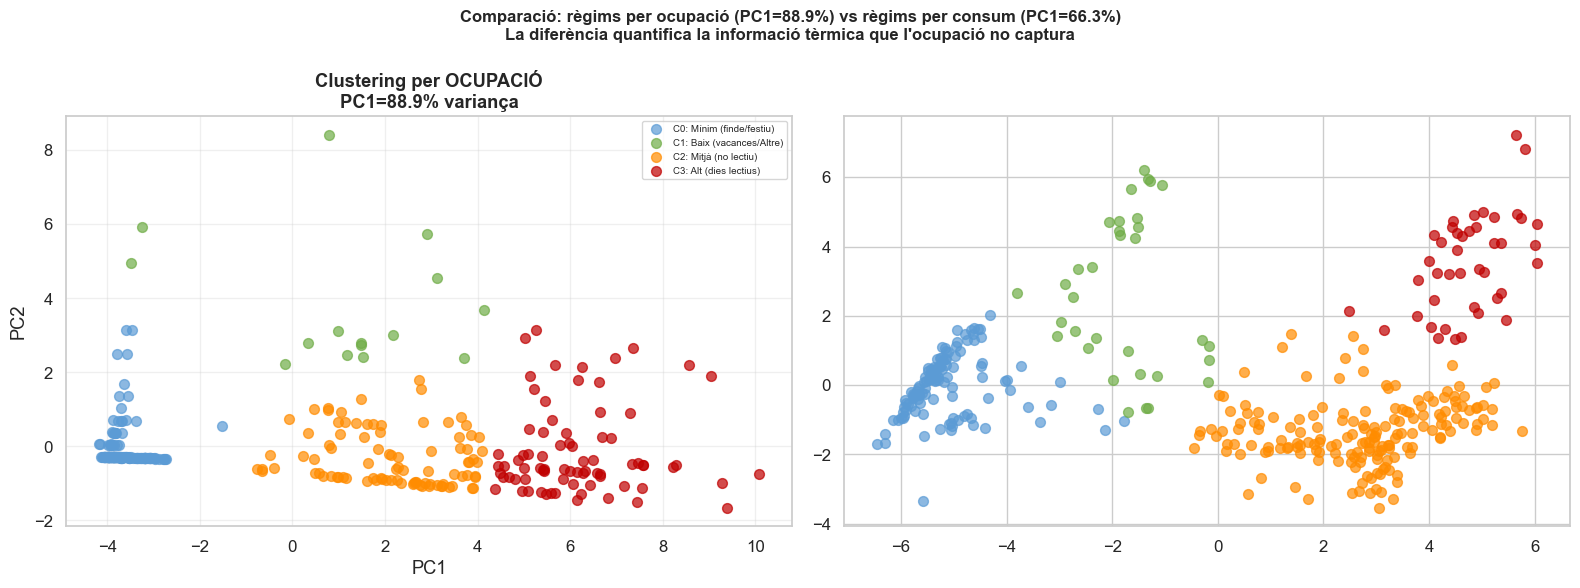


Dies amb cluster ocupació ≠ cluster consum: 179 (48.9%)
Interpretació: dies amb comportament energètic anòmal respecte al seu nivell d'activitat
✅ clustering_ocupacio_vs_consum.png


In [143]:
# ── Figura 5: Comparació espais latents ocupació vs consum ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for cl in range(K_FINAL):
    mask = pivot['cluster'] == cl
    axes[0].scatter(pivot.loc[mask, 'PC1'], pivot.loc[mask, 'PC2'],
                    s=50, alpha=0.7, color=COLORS_CL[cl],
                    label=NOMS_CL[cl].replace('\n',' '))
axes[0].set_title(f'Clustering per OCUPACIÓ\nPC1={var_exp[0]*100:.1f}% variança',
                   fontweight='bold')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].legend(fontsize=7); axes[0].grid(alpha=0.3)

for cl in range(K_FINAL):
    mask = pivot_c['cluster_consumo'] == cl
    axes[1].scatter(pivot_c.loc[mask, 'PC1_c'], pivot_c.loc[mask, 'PC2_c'],
                    s=50, alpha=0.7, color=COLORS_CL[cl], label=f'C{cl}')

plt.suptitle(
    f'Comparació: règims per ocupació (PC1={var_exp[0]*100:.1f}%) '
    f'vs règims per consum (PC1={var_c[0]*100:.1f}%)\n'
    f'La diferència quantifica la informació tèrmica que l\'ocupació no captura',
    fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / 'clustering_ocupacio_vs_consum.png', dpi=150, bbox_inches='tight')
plt.show()

# Discrepàncies entre els dos clusterings
comp = pivot[['fecha','cluster']].merge(
    pivot_c[['fecha','cluster_consumo']], on='fecha')
comp['discrepancia'] = comp['cluster'] != comp['cluster_consumo']
n_disc = comp['discrepancia'].sum()
print(f'\nDies amb cluster ocupació ≠ cluster consum: {n_disc} ({n_disc/len(comp)*100:.1f}%)')
print('Interpretació: dies amb comportament energètic anòmal respecte al seu nivell d\'activitat')
print('✅ clustering_ocupacio_vs_consum.png')

Cross-tab CONSUM (% de cada tipus_dia per cluster energètic):
                 C0    C1     C2    C3
tipus_dia                             
Classe          0.7   0.0   90.7   8.6
La Benvinguda   0.0   0.0  100.0   0.0
Avaluacio       0.0   0.0   20.0  80.0
No lectiu       0.0   0.0   16.7  83.3
Altre          27.3  12.7   58.2   1.8
Vacances       47.4  36.8   15.8   0.0
Dissabte       82.7  17.3    0.0   0.0
Diumenge       82.7  17.3    0.0   0.0
Festiu         87.5  12.5    0.0   0.0


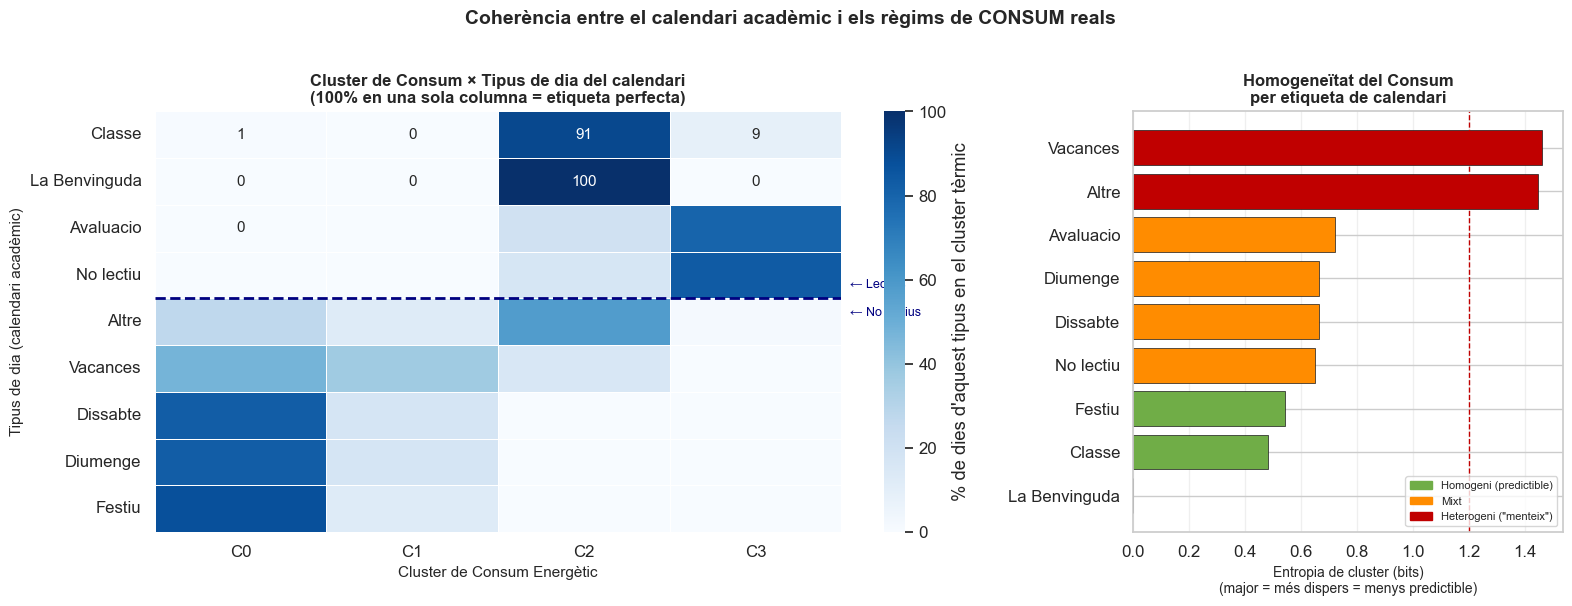


Tipus de dia amb alta dispersió TÈRMICA (calendari "menteix"):
  Vacances              entropia=1.46  n_dies=19
  Altre                 entropia=1.45  n_dies=55


In [144]:
# ── Figura 4b: Cross-tab + entropia (CLUSTERING PER CONSUM) ──────────────────
# Assegura't que 'pivot_c' és el DataFrame on tens els resultats del K-Means de consum.
# Si es diu diferent (ex. pivot_consum), canvia'l aquí sota:

cross_raw_c = pd.crosstab(pivot_c['tipus_dia'], pivot_c['cluster_consumo'])
cross_pct_c = (cross_raw_c.div(cross_raw_c.sum(axis=1), axis=0) * 100).round(1)

ORDRE_TIPUS = ['Classe','La Benvinguda','Avaluacio','No lectiu',
               'Altre','Vacances','Dissabte','Diumenge','Festiu']
ordre_disp_c = [t for t in ORDRE_TIPUS if t in cross_pct_c.index]
cross_pct_c  = cross_pct_c.reindex(ordre_disp_c)
cross_pct_c.columns = [f'C{c}' for c in cross_pct_c.columns]

print('Cross-tab CONSUM (% de cada tipus_dia per cluster energètic):')
print(cross_pct_c.to_string())

# La funció entropia ja la tens definida del bloc anterior
entr_c = cross_pct_c.apply(entropia, axis=1).sort_values(ascending=True)

# L'entropia màxima depèn de quants clústers de consum hagis generat
K_CONSUM = len(cross_pct_c.columns)
max_entr_c = np.log2(K_CONSUM)

fig, axes = plt.subplots(1, 2, figsize=(16, 6),
                          gridspec_kw={'width_ratios': [2, 1]})

# Canviem la paleta a 'Blues' per diferenciar-ho de l'ocupació
sns.heatmap(cross_pct_c, annot=True, fmt='.0f', annot_kws={'size': 11},
            cmap='Blues', linewidths=0.5,
            cbar_kws={'label': "% de dies d'aquest tipus en el cluster tèrmic"},
            ax=axes[0])
axes[0].set_title('Cluster de Consum × Tipus de dia del calendari\n'
                  '(100% en una sola columna = etiqueta perfecta)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Cluster de Consum Energètic', fontsize=11)
axes[0].set_ylabel('Tipus de dia (calendari acadèmic)', fontsize=11)

n_lect_c = len([t for t in cross_pct_c.index
              if t in ['Classe','La Benvinguda','Avaluacio','No lectiu']])
axes[0].axhline(n_lect_c, color='navy', lw=2, ls='--')
axes[0].text(K_CONSUM + 0.05, n_lect_c - 0.3, '← Lectius',
              fontsize=9, color='navy', va='center')
axes[0].text(K_CONSUM + 0.05, n_lect_c + 0.3, '← No lectius',
              fontsize=9, color='navy', va='center')

colors_entr_c = ['#C00000' if e > max_entr_c * 0.6 else
                 '#FF8C00' if e > max_entr_c * 0.3 else '#70AD47'
                 for e in entr_c]
axes[1].barh(entr_c.index, entr_c.values,
              color=colors_entr_c, edgecolor='k', linewidth=0.5)
axes[1].axvline(max_entr_c * 0.6, color='#C00000', ls='--', lw=1)
axes[1].set_xlabel('Entropia de cluster (bits)\n(major = més dispers = menys predictible)',
                    fontsize=10)
axes[1].set_title('Homogeneïtat del Consum\nper etiqueta de calendari',
                   fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3, axis='x')

import matplotlib.patches as mpatches
patches = [mpatches.Patch(color='#70AD47', label='Homogeni (predictible)'),
           mpatches.Patch(color='#FF8C00', label='Mixt'),
           mpatches.Patch(color='#C00000', label='Heterogeni ("menteix")')]
axes[1].legend(handles=patches, fontsize=8, loc='lower right')

plt.suptitle('Coherència entre el calendari acadèmic i els règims de CONSUM reals',
              fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES / 'crosstab_cluster_consum_calendari.png', dpi=150, bbox_inches='tight')
plt.show()

# Resum quantitatiu
print('\nTipus de dia amb alta dispersió TÈRMICA (calendari "menteix"):')
for tipus, e in entr_c[entr_c > max_entr_c * 0.6].sort_values(ascending=False).items():
    n = cross_raw_c.loc[tipus].sum()
    print(f'  {tipus:20s}  entropia={e:.2f}  n_dies={n}')

---
## PART C — DBSCAN: detecció d'HORES anòmales

Opera a nivell d'**hora individual** (no de dia).  
Detecta hores atípiques en el pla (ocupació, consum, temperatura):  
- Consum molt alt de matinada amb gent = equip oblidat encès  
- Consum molt alt sense gent = HVAC mal calibrat  
- Ocupació molt alta sense consum = error de mesura  

**Nota**: aquí SÍ s'usa `Consumo_kWh` com a feature perquè l'objectiu  
és detectar anomalies en totes les dimensions alhora, no crear un predictor.

✅  eps autodetectat: 0.354  → 2.0% anomalies


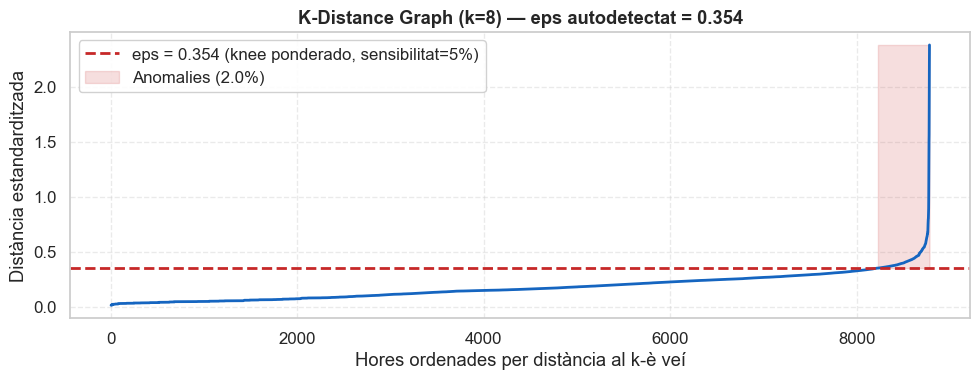

eps final: 0.354  |  min_samples: 8


In [145]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
import numpy as np
import matplotlib.pyplot as plt

# ── Features per DBSCAN (hores individuals) ──────────────────────────────────
feats_dbscan = ['Consumo_kWh', 'Ocupacion_Simulada', 'hora', 'Temperatura']
df_db = df[feats_dbscan].dropna().copy()

X_db     = StandardScaler().fit_transform(df_db.values)
idx_db   = df_db.index  # per recuperar les hores originals

MIN_SAMPLES = 8
neigh = NearestNeighbors(n_neighbors=MIN_SAMPLES)
neigh.fit(X_db)
dists, _ = neigh.kneighbors(X_db)
dists_sorted = np.sort(dists[:, MIN_SAMPLES - 1])

def knee_ponderado(dists_sorted, sensibilitat=0.05):
    n   = len(dists_sorted)
    x   = np.linspace(0, 1, n)
    y   = (dists_sorted - dists_sorted.min()) / \
          (dists_sorted.max() - dists_sorted.min())
    vec = np.array([x[-1]-x[0], y[-1]-y[0]])
    vec = vec / np.linalg.norm(vec)
    vecs = np.column_stack([x - x[0], y - y[0]])
    perp = np.abs(np.cross(vec, vecs))
    umbral = np.percentile(perp, (1 - sensibilitat) * 100)
    idx = np.where(perp >= umbral)[0][0]
    return float(dists_sorted[idx])

EPS_AUTO = knee_ponderado(dists_sorted, sensibilitat=0.05)

# Validació: entre 0.5% i 5% d'anomalies és raonable
db_test  = DBSCAN(eps=EPS_AUTO, min_samples=MIN_SAMPLES).fit_predict(X_db)
pct_anom = (db_test == -1).mean() * 100

if pct_anom < 0.5:
    print(f'⚠️  eps autodetectat ({EPS_AUTO:.3f}) detecta massa poques anomalies '
          f'({pct_anom:.1f}%). Ajustant a 0.6...')
    EPS_AUTO = 0.6
elif pct_anom > 5.0:
    print(f'⚠️  eps autodetectat ({EPS_AUTO:.3f}) detecta massa anomalies '
          f'({pct_anom:.1f}%). Ajustant a 0.6...')
    EPS_AUTO = 0.6
else:
    print(f'✅  eps autodetectat: {EPS_AUTO:.3f}  → {pct_anom:.1f}% anomalies')

EPS = EPS_AUTO

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(dists_sorted, lw=2, color='#1565C0')
ax.axhline(EPS, color='#C62828', ls='--', lw=2,
           label=f'eps = {EPS:.3f} (knee ponderado, sensibilitat=5%)')
ax.fill_between(range(len(dists_sorted)), EPS, dists_sorted.max(),
                where=(dists_sorted > EPS), color='#C62828', alpha=0.15,
                label=f'Anomalies ({pct_anom:.1f}%)')
ax.set_title(f'K-Distance Graph (k={MIN_SAMPLES}) — eps autodetectat = {EPS:.3f}',
              fontweight='bold')
ax.set_xlabel('Hores ordenades per distància al k-è veí')
ax.set_ylabel('Distància estandarditzada')
ax.legend(loc='upper left', framealpha=0.9)
ax.grid(alpha=0.4, ls='--')
plt.tight_layout()
plt.savefig(FIGURES / 'dbscan_kdistance.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'eps final: {EPS:.3f}  |  min_samples: {MIN_SAMPLES}')

In [146]:
# ── DBSCAN ───────────────────────────────────────────────────────────────────
db = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES)
labels_db = db.fit_predict(X_db)

df_db = df.loc[idx_db].copy()
df_db['cluster_db'] = labels_db
df_db['anomalia']     = labels_db == -1

n_anomalies  = (labels_db == -1).sum()
n_rutina     = (labels_db != -1).sum()
n_clusters   = len(set(labels_db)) - (1 if -1 in labels_db else 0)

print(f'DBSCAN: {n_clusters} clusters de rutina | {n_anomalies} hores anòmales ({n_anomalies/len(labels_db)*100:.1f}%)')

# Caracteritzar les anomalies
anom = df_db[df_db['anomalia']]
print(f'\nCaracterístiques de les hores anòmales:')
print(anom[['Consumo_kWh','Ocupacion_Simulada','hora','Temperatura']].describe().round(1))

print(f'\nAnomàlies per tipus de dia:')
print(anom.groupby(COL_TIPUS).size().sort_values(ascending=False))

print(f'\nAnomàlies per franja horària:')
anom_hora = anom.groupby('hora').size()
print(anom_hora[anom_hora > 0].to_string())

DBSCAN: 4 clusters de rutina | 172 hores anòmales (2.0%)

Característiques de les hores anòmales:
       Consumo_kWh  Ocupacion_Simulada   hora  Temperatura
count        172.0               172.0  172.0        172.0
mean         308.5              1259.2   14.6         15.4
std          106.2               770.7    3.9          7.4
min            0.0                 3.0    0.0          3.0
25%          278.8               592.2   11.0          8.6
50%          325.0              1260.0   14.0         14.1
75%          381.2              1846.5   18.0         22.3
max          471.0              2934.0   23.0         33.5

Anomàlies per tipus de dia:
tipus_dia
Classe           108
Avaluacio         34
Altre             13
Vacances          13
No lectiu          2
Festiu             1
La Benvinguda      1
dtype: int64

Anomàlies per franja horària:
hora
0      1
8      1
9     13
10    16
11    14
12    15
13    14
14    14
15     7
16    10
17    18
18    19
19    12
20     7
21     8
2

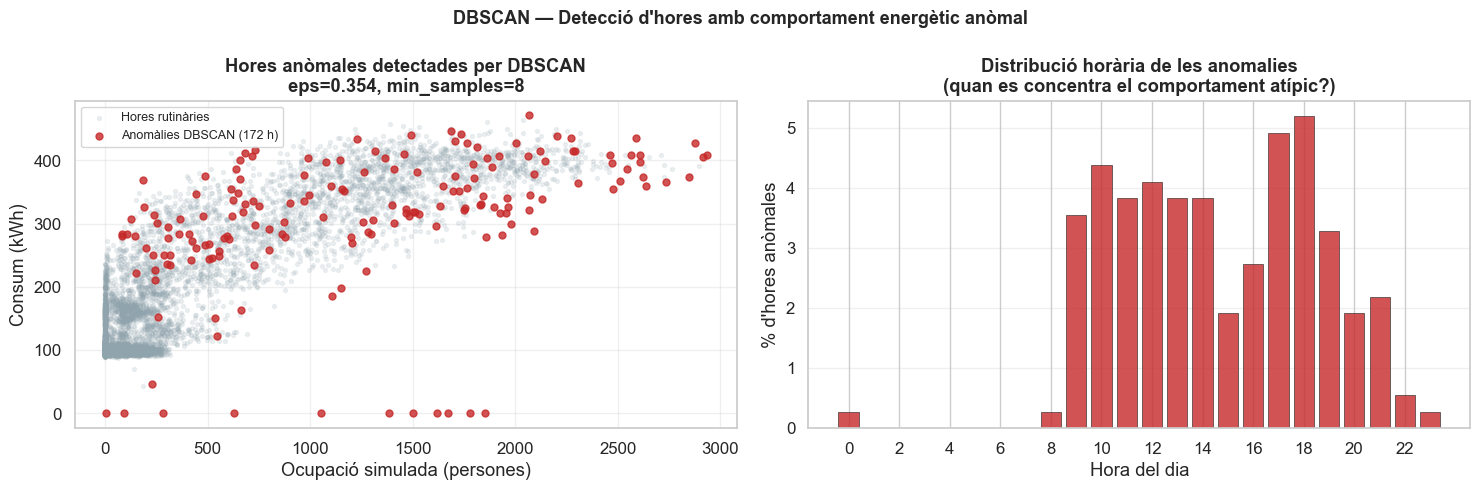

✅ dbscan_anomalies.png


In [147]:
# ── Figura 6: DBSCAN scatter + mapa temporal d'anomalies ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Panel esquerre: scatter ocupació vs consum
rutina = df_db[~df_db['anomalia']]
axes[0].scatter(rutina['Ocupacion_Simulada'], rutina['Consumo_kWh'],
                alpha=0.15, s=8, color='#90A4AE', label='Hores rutinàries')
axes[0].scatter(anom['Ocupacion_Simulada'], anom['Consumo_kWh'],
                alpha=0.8, s=25, color='#C62828',
                label=f'Anomàlies DBSCAN ({n_anomalies} h)', zorder=4)
axes[0].set_xlabel('Ocupació simulada (persones)')
axes[0].set_ylabel('Consum (kWh)')
axes[0].set_title(f'Hores anòmales detectades per DBSCAN\n'
                    f'eps={EPS:.3f}, min_samples={MIN_SAMPLES}',
                    fontweight='bold')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

# Panel dret: distribució horària de les anomalies (quan ocorren?)
anom_per_hora = df_db.groupby('hora')['anomalia'].sum()
total_per_hora = df_db.groupby('hora').size()
pct_anom_hora  = (anom_per_hora / total_per_hora * 100).fillna(0)

axes[1].bar(range(24), pct_anom_hora.values,
             color='#C62828', alpha=0.8, edgecolor='k', linewidth=0.5)
axes[1].set_xlabel('Hora del dia')
axes[1].set_ylabel('% d\'hores anòmales')
axes[1].set_title('Distribució horària de les anomalies\n'
                    '(quan es concentra el comportament atípic?)',
                    fontweight='bold')
axes[1].set_xticks(range(0, 24, 2))
axes[1].grid(alpha=0.3, axis='y')

plt.suptitle('DBSCAN — Detecció d\'hores amb comportament energètic anòmal',
              fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / 'dbscan_anomalies.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ dbscan_anomalies.png')

In [148]:
# ── Inspecció de les hores anòmales ──────────────────────────────────────────
index_anomalies = df_db[df_db['cluster_db'] == -1].index

df_anomalies = df.loc[index_anomalies].copy()

columnes_veure = ['Timestamp', 'fecha']   # context temporal
if COL_TIPUS in df.columns:
    columnes_veure.append(COL_TIPUS)
columnes_veure += ['hora', 'Ocupacion_Simulada', 'Consumo_kWh', 'Temperatura']
columnes_veure = [c for c in columnes_veure if c in df_anomalies.columns]

df_mostrar = df_anomalies[columnes_veure].sort_values('Consumo_kWh', ascending=False)

print(f'🕵️  {len(df_mostrar)} hores anòmales detectades — top 20 per consum:')
print('-' * 80)
print(df_mostrar.head(20).to_string(index=False))

# ── Patrons: quines dates es repeteixen? ────────────────────────────────────
print('\nDates amb més anomalies (top 10):')
top_dates = df_anomalies.groupby('fecha').size().sort_values(ascending=False).head(10)
for fecha, n in top_dates.items():
    tipus = df_anomalies[df_anomalies['fecha'] == fecha][COL_TIPUS].iloc[0] \
            if COL_TIPUS in df_anomalies.columns else '?'
    consum = df_anomalies[df_anomalies['fecha'] == fecha]['Consumo_kWh'].mean()
    ocup   = df_anomalies[df_anomalies['fecha'] == fecha]['Ocupacion_Simulada'].mean()
    print(f'  {fecha}  {tipus:15s}  {n} h anòmales  '
          f'consum_mig={consum:.0f} kWh  ocup_mitja={ocup:.0f} p')

print('\nClassificació per tipus d\'anomalia:')

# 1. Alt consum, baixa ocupació → malbaratament HVAC (lo típico)
mask_hvac = ((df_anomalies['Consumo_kWh'] >=
              df_anomalies['Consumo_kWh'].quantile(0.50)) &
             (df_anomalies['Ocupacion_Simulada'] <=
              df_anomalies['Ocupacion_Simulada'].quantile(0.25)))

# 2. Alt consum, alta ocupació → pic d'activitat legítim
mask_pic  = ((df_anomalies['Consumo_kWh'] >
              df_anomalies['Consumo_kWh'].quantile(0.50)) &
             (df_anomalies['Ocupacion_Simulada'] >=
              df_anomalies['Ocupacion_Simulada'].quantile(0.25)))

# 3. Alt Baix consum
#    (normalment lògic: poca gent → poc consum, però DBSCAN els marca com raros
#     perquè la combinació ESPECÍFICA d'ocupació i temperatura és inusual)
mask_baix = ((df_anomalies['Consumo_kWh'] <
              100)) 

# 4. La resta
mask_altres = ~mask_hvac & ~mask_pic & ~mask_baix

print(f'  Malbaratament HVAC (alt consum, poca gent):     {mask_hvac.sum():4d} h ({mask_hvac.mean()*100:.1f}%)')
print(f'  Pic d\'activitat   (alt consum, molta gent):     {mask_pic.sum():4d} h ({mask_pic.mean()*100:.1f}%)')
print(f'  Demanda baixa rara (consum molt baix):    {mask_baix.sum():4d} h ({mask_baix.mean()*100:.1f}%)')
print(f'  Altres anomalies:                               {mask_altres.sum():4d} h ({mask_altres.mean()*100:.1f}%)')

# Inspection dels punts de baix
if mask_baix.sum() > 0:
    print(f'\n🔍 Detall dels {mask_baix.sum()} casos de demanda baixa rara:')
    df_baix = df_anomalies[mask_baix][[
        'Timestamp', 'hora', 'Ocupacion_Simulada', 'Consumo_kWh', 'Temperatura'
    ]].sort_values('Consumo_kWh')
    print(df_baix.head(15).to_string(index=False))
    
    print(f'\n  Temperatures en aquests casos:')
    print(f'    min={df_baix["Temperatura"].min():.1f}°C  med={df_baix["Temperatura"].median():.1f}°C  max={df_baix["Temperatura"].max():.1f}°C')
    print()

🕵️  172 hores anòmales detectades — top 20 per consum:
--------------------------------------------------------------------------------
          Timestamp      fecha tipus_dia  hora  Ocupacion_Simulada  Consumo_kWh  Temperatura
2024-02-15 12:00:00 2024-02-15    Classe    12              2066.0          471         19.7
2024-01-08 12:00:00 2024-01-08    Classe    12              1686.0          447         11.2
2024-06-18 14:00:00 2024-06-18 Avaluacio    14              1736.0          441         25.5
2024-01-10 15:00:00 2024-01-10    Classe    15              1491.0          440          8.6
2024-01-10 13:00:00 2024-01-10    Classe    13              2206.0          439         10.1
2024-01-10 12:00:00 2024-01-10    Classe    12              2274.0          436          8.7
2024-02-13 12:00:00 2024-02-13    Classe    12              2588.0          435         14.7
2024-01-10 17:00:00 2024-01-10    Classe    17              1230.0          433          7.2
2024-06-19 12:00:00 2024-06

---
## Visualització 3D interactiva

In [149]:
import plotly.express as px

# Afegir etiquetes llegibles al dataset hora-a-hora
df_3d = df.merge(pivot[['fecha','cluster']], on='fecha', how='left')
df_3d['Règim'] = df_3d['cluster'].map({
    0: 'C0: Mínim', 1: 'C1: Baix', 2: 'C2: Mitjà', 3: 'C3: Alt'
}).fillna('Desconegut')

# Mostra 1 de cada 3 punts per rendiment (el dataset complet pot ser lent)
df_3d_sample = df_3d.iloc[::3].copy()

fig3d = px.scatter_3d(
    df_3d_sample,
    x='Ocupacion_Simulada',
    y='Temperatura',
    z='Consumo_kWh',
    color='Règim',
    color_discrete_map={
        'C0: Mínim': '#5B9BD5', 'C1: Baix': '#70AD47',
        'C2: Mitjà': '#FF8C00', 'C3: Alt':  '#C00000'
    },
    hover_data=[COL_TIPUS, 'hora', 'mes'],
    title='Règims operatius del campus UPF Poblenou 2024 — 3D interactiu',
    opacity=0.6,
    labels={
        'Ocupacion_Simulada': 'Ocupació (persones)',
        'Temperatura':         'Temperatura (°C)',
        'Consumo_kWh':         'Consum (kWh)',
    }
)
fig3d.update_traces(marker=dict(size=3, line=dict(width=0.3, color='DarkSlateGrey')))
fig3d.update_layout(
    scene=dict(
        xaxis_title='Ocupació (persones)',
        yaxis_title='Temperatura (°C)',
        zaxis_title='Consum (kWh)'
    ),
    margin=dict(l=0, r=0, b=0, t=40),
    legend_title_text='Règim operatiu'
)
fig3d.show()

out_html = FIGURES / 'kmeans_3d_interactiu.html'
fig3d.write_html(str(out_html))
print(f'✅ Gràfic interactiu guardat: {out_html}')

c:\Users\jordi\anaconda3\Lib\site-packages\plotly\express\_core.py:1979: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.



✅ Gràfic interactiu guardat: ..\outputs\figures\kmeans_3d_interactiu.html


---
## Exports i resum final

In [150]:
# ── Export: dies amb cluster (per usar com feature al model) ──────────────────
pivot[['fecha','tipus_dia','cluster','consum_mitja','ocup_mitja']].to_csv(
    DATA_PROCESSED / 'dias_con_cluster.csv', index=False
)

# ── Export: hores amb label DBSCAN (per auditoria energètica) ─────────────────
df_db[['Timestamp',COL_TIPUS,'hora','Consumo_kWh',
           'Ocupacion_Simulada','Temperatura','anomalia']].to_csv(
    DATA_PROCESSED / 'hores_dbscan_anomalies.csv', index=False
)

print('═' * 60)
print('RESUM DE RESULTATS')
print('═' * 60)
print(f"""
PART A — Clustering per OCUPACIÓ (k={K_FINAL}):
  PC1 variança:   {var_exp[0]*100:.1f}%  (el campus és quasi 1D en activitat)
  Silhouette k=4: {sil_means[list(K_RANGE).index(4)]:.3f}

  Anàlisi de punts negatius per k (justificació de k=4):
""")
for k, sil, negs in zip(K_RANGE, sil_means, sil_negs):
    marca = ' ← SELECCIONAT' if k == K_FINAL else ''
    print(f'    k={k}:  sil={sil:.3f}  negatius={negs:2d} punts{marca}')

print(f"""
  → k=4 supera k=3 en silhouette ({sil_means[list(K_RANGE).index(4)]:.3f} > {sil_means[list(K_RANGE).index(3)]:.3f})
    amb el mateix nombre de punts negatius ({sil_negs[list(K_RANGE).index(4)]}).
    k=5 es degrada ({sil_negs[list(K_RANGE).index(5)]} negatius, sil={sil_means[list(K_RANGE).index(5)]:.3f}).
    Conclusió: k=4 és l\'òptim estadístic I operatiu.

  Tipus heterogenis (entropia alta):""")
for t, e in entr[entr > max_entr * 0.6].sort_values(ascending=False).items():
    n = cross_raw.loc[t].sum()
    print(f'    {t:20s}  entropia={e:.2f}  n_dies={n}')
for t, e in entr[entr > max_entr * 0.6].sort_values(ascending=False).items():
    print(f'    {t}: entropia={e:.2f}')
print(f"""
PART B — Clustering per CONSUM:
  PC1 variança:   {var_c[0]*100:.1f}%  (menys unidimensional que ocupació)
  Dimensió extra: {(1-var_c[0])*100:.1f}% (tèrmica + operativa)
  Outlier:        {pivot_c.loc[outlier_idx,'fecha']} (consum standby, ocup=0)

PART C — DBSCAN anomalies (hores):
  Hores anòmales: {n_anomalies} ({n_anomalies/len(labels_db)*100:.1f}% del any)
  Clusters rutina: {n_clusters}

EXPORTS:
  dias_con_cluster.csv      → feature per al model XGBoost
  hores_dbscan_anomalies.csv → input per a auditoria energètica
  kmeans_3d_interactiu.html  → presentació oral tribunal
""")
print('═' * 60)

════════════════════════════════════════════════════════════
RESUM DE RESULTATS
════════════════════════════════════════════════════════════

PART A — Clustering per OCUPACIÓ (k=4):
  PC1 variança:   88.9%  (el campus és quasi 1D en activitat)
  Silhouette k=4: 0.671

  Anàlisi de punts negatius per k (justificació de k=4):

    k=2:  sil=0.716  negatius= 2 punts
    k=3:  sil=0.661  negatius= 3 punts
    k=4:  sil=0.671  negatius= 3 punts ← SELECCIONAT
    k=5:  sil=0.624  negatius= 6 punts
    k=6:  sil=0.637  negatius= 4 punts
    k=7:  sil=0.628  negatius= 3 punts
    k=8:  sil=0.619  negatius= 5 punts

  → k=4 supera k=3 en silhouette (0.671 > 0.661)
    amb el mateix nombre de punts negatius (3).
    k=5 es degrada (6 negatius, sil=0.624).
    Conclusió: k=4 és l'òptim estadístic I operatiu.

  Tipus heterogenis (entropia alta):
    Classe                entropia=1.35  n_dies=140
    Classe: entropia=1.35

PART B — Clustering per CONSUM:
  PC1 variança:   66.3%  (menys unidimensi